In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import add_messages
from typing import TypedDict, Sequence, Annotated
from langchain_core.messages import BaseMessage


class MyState(TypedDict):
    jokes: Sequence[BaseMessage]

class OverallState(TypedDict):
    topic: str
    subjects: list[str]
    best_selected_joke: str
    jokes: Annotated[Sequence[BaseMessage], add_messages]

In [2]:
def generate_topics(state: OverallState):
    return {"subjects": ["lions", "elephants", "penguins"]}

In [3]:
from langgraph.types import Send

def continue_to_jokes(state: OverallState):
    return [Send("generate_joke", {"subject": s}) for s in state["subjects"]]

In [4]:
def generate_joke(state: OverallState):
    joke_map = {
        "lions": "Why don't lions like fast food? Because they can't catch it!",
        "elephants": "Why don't elephants use computers? They're afraid of the mouse!",
        "penguins": "Why don't penguins like talking to strangers at parties? Because they find it hard to break the ice."
    }
    return {"jokes": [joke_map[state["subject"]]]}

In [5]:
def generate_joke(state: OverallState):
    joke_map = {
        "lions": "Why don't lions like fast food? Because they can't catch it!",
        "elephants": "Why don't elephants use computers? They're afraid of the mouse!",
        "penguins": "Why don't penguins like talking to strangers at parties? Because they find it hard to break the ice."
    }
    return {"jokes": [joke_map[state["subject"]]]}

In [6]:
def best_joke(state: OverallState):
    return {"best_selected_joke": "penguins"}

In [7]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(OverallState)

builder.add_node("generate_topics", generate_topics)
builder.add_node("generate_joke", generate_joke)
builder.add_node("best_joke", best_joke)

builder.add_edge(START, "generate_topics")
builder.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
builder.add_edge("generate_joke", "best_joke")
builder.add_edge("best_joke", END)

graph = builder.compile()

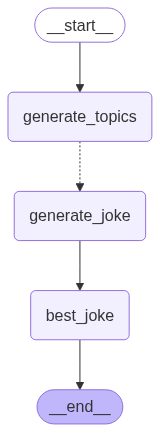

In [8]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
# Call the graph: here we call it to generate a list of jokes
for step in graph.stream({"topic": "animals"}):
    print(step)

{'generate_topics': {'subjects': ['lions', 'elephants', 'penguins']}}
{'generate_joke': {'jokes': ["Why don't elephants use computers? They're afraid of the mouse!"]}}
{'generate_joke': {'jokes': ["Why don't lions like fast food? Because they can't catch it!"]}}
{'generate_joke': {'jokes': ["Why don't penguins like talking to strangers at parties? Because they find it hard to break the ice."]}}
{'best_joke': {'best_selected_joke': 'penguins'}}


In [10]:
#Generate all jokes manually in one node
def generate_all_jokes(state: OverallState):
    joke_map = {
        "lions": "Why don't lions like fast food? Because they can't catch it!",
        "elephants": "Why don't elephants use computers? They're afraid of the mouse!",
        "penguins": "Why don't penguins like talking to strangers at parties? Because they find it hard to break the ice."
    }

    jokes = []
    for subject in state["subjects"]:
        jokes.append(joke_map.get(subject, "No joke found"))
    
    return {"jokes": jokes}

# Build the graph manually without Send API
builder1 = StateGraph(OverallState)
builder1.add_node("generate_topics", generate_topics)
builder1.add_node("generate_all_jokes", generate_all_jokes)
builder1.add_node("best_joke", best_joke)

builder1.add_edge(START, "generate_topics")
builder1.add_edge("generate_topics", "generate_all_jokes")
builder1.add_edge("generate_all_jokes", "best_joke")
builder1.add_edge("best_joke", END)

graph1 = builder1.compile()

In [11]:
for step in graph1.stream({"topic": "animals"}):
    print(step)

{'generate_topics': {'subjects': ['lions', 'elephants', 'penguins']}}
{'generate_all_jokes': {'jokes': ["Why don't lions like fast food? Because they can't catch it!", "Why don't elephants use computers? They're afraid of the mouse!", "Why don't penguins like talking to strangers at parties? Because they find it hard to break the ice."]}}
{'best_joke': {'best_selected_joke': 'penguins'}}
